<h1 style="text-align: center;">TP2 - Projeto de Bloco: Ciência da Computação</h1>

| 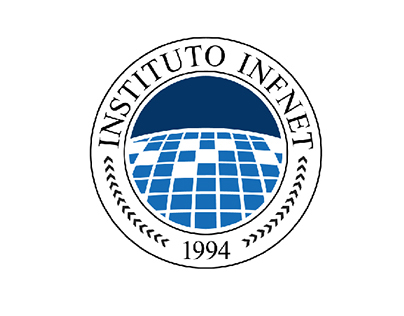 |
|:-------------------------------------------------------------------------:|


<h5 style="text-align: center;">Professor: Ricardo Pires Mesquita || Estudante: Paulo Henrique de Paula Dias</h5>

<h5 style="text-align: center;">Data limite: 30/03/2026</h5>

##### Links úteis:

Repositório Git Hub - [Link](https://github.com/PAULOHENRIQUEDEPAULADIAS/Paulo_Dias_PBCC_TP2_JP/upload)

OBS: Esse trabalho me apresentou mais dificuldade do que o habitual. Os exercícios 11 e 12 não foram resolvidos.

#### Grupo 1: Exercícios para desenvolver processos assíncronos e paralelos, integrando asyncio e OpenMP para otimização de tarefas computacionais.



1 - Usando OpenMP, implemente um programa que calcule o valor de $π$ usando o método de integração numérica. Neste exercício clássico, vamos explorar três conceitos fundamentais de paralelismo: divisão de carga, variáveis privadas versus compartilhadas e redução.

O objetivo é aproximar o valor de $π$ calculando a área sob a curva delimitada por $f(x)=\frac{4}{1+x^2}$ no intervalo $[0,1]$, ou seja, deve-se calcular computacionalmente $\int_{0}^{1}\frac{4}{1+x^2}dx$ e observar que o valor encontrado aproxima-se do número $π$.

Para tal objetivo, você deve calcular a integral como a soma das áreas de um número grande de retângulos, digamos, num_passos = 100.000.000.

Dicas:

* Use a diretiva **#pragma omp parallel for** para dividir as iterações entre as threads.
* Use a cláusula **reduction(+:sum)** para evitar uma condição de corrida, garantindo que cada thread some sua parte corretamente no total final.
* Use a cláusula **private(x)** para que cada thread tenha sua própria cópia da variável de cálculo intermediário.
* Use a flag **-fopenmp** no seu compilador (como o GCC) para ativar o suporte ao OpenMP:
    * **gcc -fopenmp programa_pi.c -o programa_pi**

Para os testes:

* Execute com 1 thread (simula execução sequencial):
    * **export OMP_NUM_THREADS=1; ./programa_pi**


* Execute com 4 threads (por exemplo):
    * **export OMP_NUM_THREADS=4; ./programa_pi**

Sugestão:

* Você pode medir o tempo de execução usando **omp_get_wtime()** e comparar o código com 1, 2, 4 ou mais threads para ver o speedup real!

Antes de iniciar o exercício, é importante definir alguns conceitos vistos no enunciado:

* OpenMP: É uma API que permite você transformar um programa sequêncial em paralelo, dividindo o trabalho total em vários trabalhadores, melhorando o tempo de execução;
* Lead balancing (Divisão de Carga): Onde cada thread é responsável por uma parte do trabalho, diferentes trabalhadores responsáveis por uma parte do todo;
* Variáveis privadas vs compartilhadas: Possuem diferença de permissões, onde variáveis compartilhadas, todas as threads conseguem visualizar e mexer na mesma variável, enquanto a variável privada é restrita a sua thread correspondente, que possui sua própria cópia da variável.
* Reduction (Redução): Permite que cada thread some seus próprios resultados individualmente, e ao final, é feita a somatória dos resultados de todas as threads.


À partir daqui, apresento inicialmente um pseudo código para a estrutura resposta:

'''

    passos = 100000000
    intervalo = 1/passos #isso se dá pois estamos dividindo o intervalo \[0, 1] em n passos
    soma = 0

    #pragma omp parallel for private(x) reduction(+:soma)
    para i de 0 até passos:
      
      x = (x + 0.5) * intervalo #isso garante a aquisição do ponto no meio de cada retângulo
      
      soma += 4 / (1 + x * x)
    
    pi = soma * intervalo
    
'''

Em C, esse pseudo código, já configurado com notações omp, seria conforme abaixo:

'''

    #include <stdio.h>
    #include <omp.h>
    
    int main(){
        long long passos = 100000000;
        double intervalo = 1.0 / (double) passos;
        double soma = 0.0;
        double x;
        double pi;

        double inicio, fim;

        inicio = omp_get_wtime()
    
        #pragma omp parallel for private(x) reduction(+:soma)
        for (long long i = 0; i < passos; i++){
            x = (i + 0.5) * intervalo;
            soma += 4.0 / (1.0 + x * x);
        }
    
        pi = soma * intervalo;

        fim = omp_get_wtime();

        double tempo = fim - inicio;
    
        printf("Valorde pi: %.15f\n", pi);
        printf("Tempo de execucao: %f segundos\n", tempo);
    
        return 0;
    
    }

'''

Criando um arquivo via terminal .c denominado programa_pi.c. Para compilar primeiro rodo "gcc -fopenmp programa_pi.c -o programa_pi" no terminal, e para executar rodo "export OMP_NUM_THREADS=1; ./programa_pi" alterando o número de threads para verificar diferentes tempos de execução, com o seguinte resultado:

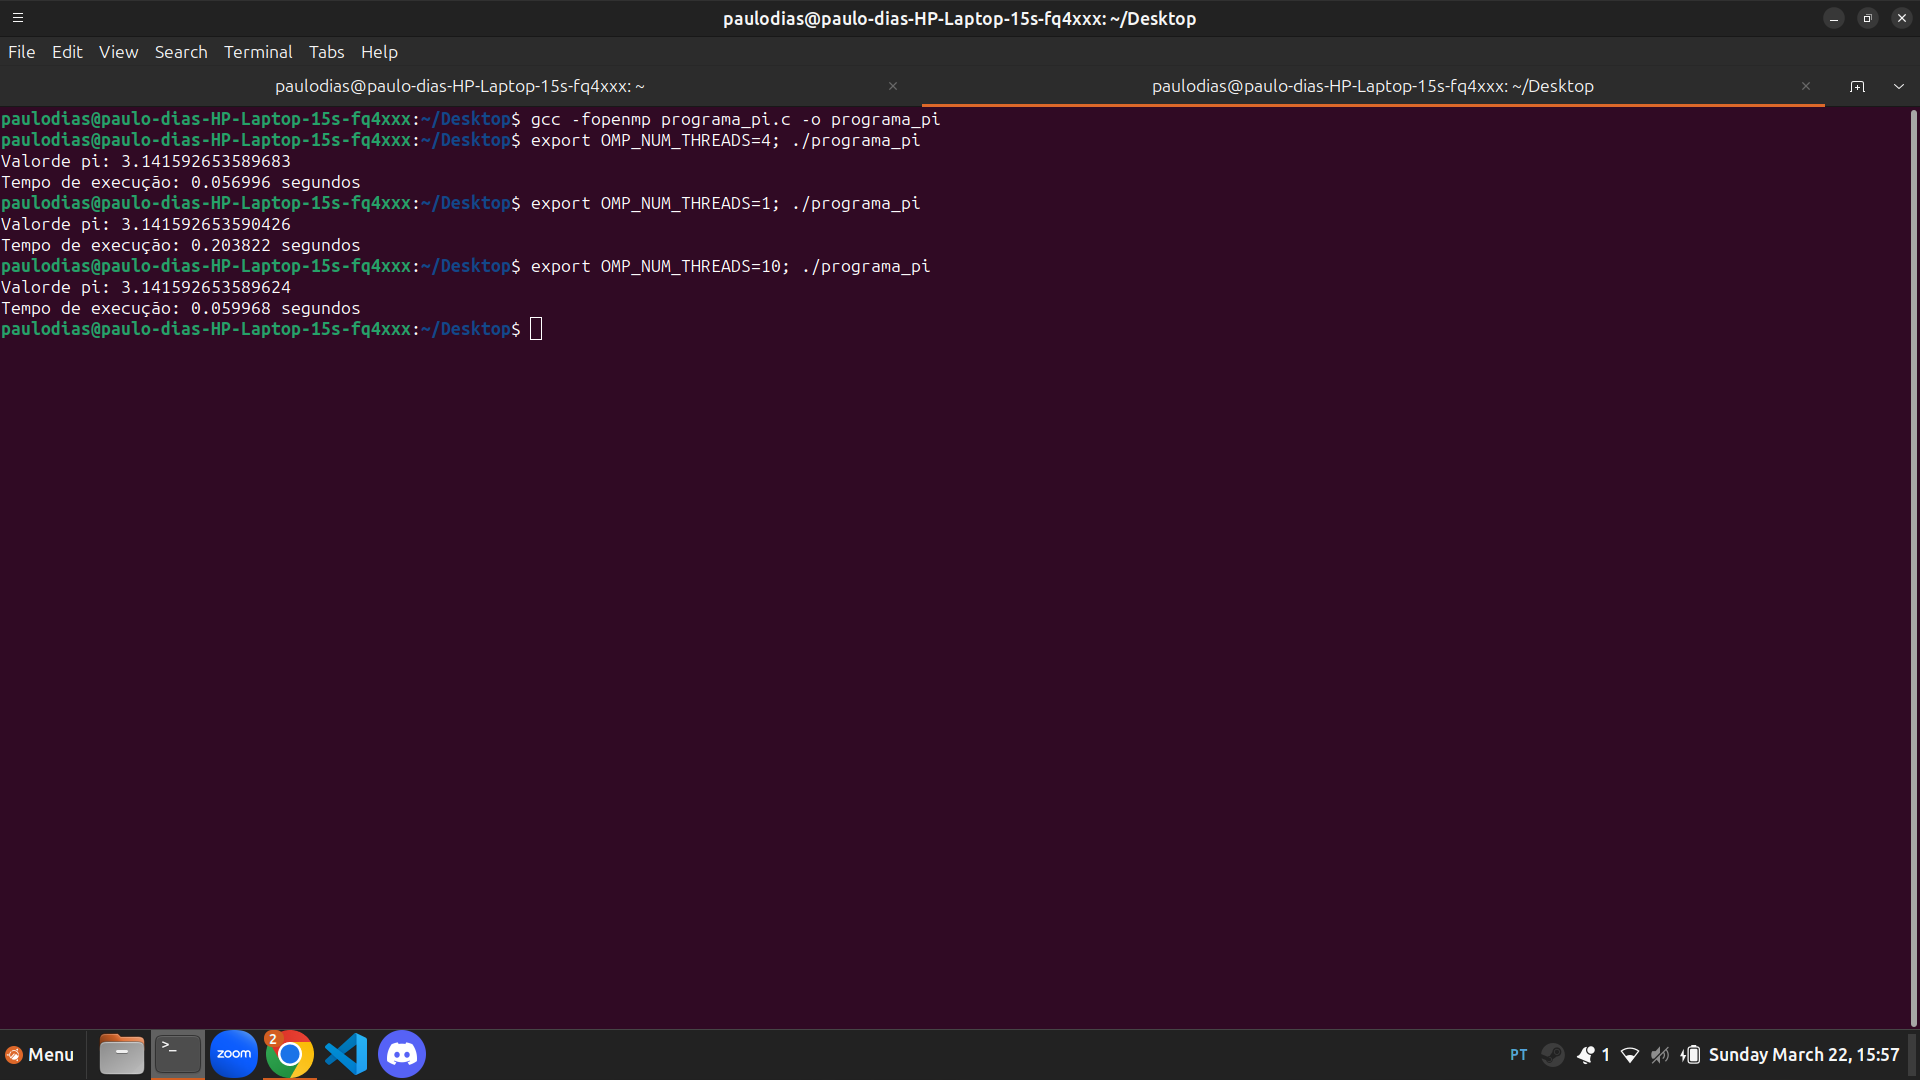

Entretando, é de se notar que não há tanta diferença entre 4 threads e 10 threads (0.002972 milisegundos de melhoramento).

2 - Você foi contratado para desenvolver o motor de um novo gerenciador de downloads. O sistema não pode travar a interface do usuário enquanto baixa arquivos e deve ser capaz de processar múltiplos arquivos ao mesmo tempo para economizar tempo do usuário.

O Problema:

Se usarmos programação síncrona (comum), o download de 10 arquivos de 2 segundos cada levaria 20 segundos no total. Sua missão é reduzir esse tempo para aproximadamente o tempo do download mais longo, usando asyncio.

Requisitos da Tarefa:

* Criação de Corrotina: Crie uma função assíncrona chamada baixar_arquivo(nome_arquivo).
* Simulação de I/O: Dentro dela, use asyncio.sleep() com um tempo aleatório entre 1 e 5 segundos para simular o tempo de rede.
* Logs de Status: O programa deve imprimir quando cada download começa e quando termina.
* Execução Concorrente: No bloco principal (main), dispare o download de uma lista com pelo menos 5 arquivos simultaneamente.
* Relatório Final: Ao final, exiba o tempo total de execução do programa e a lista de arquivos "baixados".
* Implemente um tratamento onde, se um arquivo específico (ex: "virus.exe") for solicitado, a corrotina lance uma exceção, mas permita que todos os outros downloads terminem com sucesso.

Antes de iniciar o projeto, entender alguns conceitos:

* asyncio - Refere-se a asincrono;
* corrotina - Refere-se a uma funcao que pausa, aguarda algo, e continua depois da pausa;
* asyncio.sleep() - Refere-se a uma funcao que simula uma pausa;

Para resolucao deste problema, executo conforme abaixo:

In [1]:
import asyncio
import time
import random

async def baixar_arquivo(nome): #funcao destinada a simular baixar o arquivo
    if "virus" not in nome: #Verificacao de arquivo suspeito
        print(f"{nome} comecou")
        # await asyncio indica uma asincronia, e sleep indica aguardar n segundos neste espaco sem bloquear outras tasks
        await asyncio.sleep(random.uniform(1, 5)) 
        print(f"{nome} terminou")
        return nome
    else:
        raise Exception(f"Arquivo {nome} suspeito!")

async def main():
    print(f"Iniciou : {time.strftime('%X')}") #indica o inicio da execucao de main
    
    arquivos = ["arquivo1", "arquivo2", "arquivo3", "arquivo4", "arquivo5",
    "arquivo6", "arquivo7", "arquivo8", "arquivo9", "virus.exe"
    ] #Nomes ficticios dos arquivos

    tasks = []
    
    for nome in arquivos:
        task = asyncio.create_task(baixar_arquivo(nome))
        tasks.append(task)
                                        
    #gather reune as tasks a serem executadas de forma asincrona e return_exceptions=True permite o codigo seguir sem ser interrompido
    resultado = await asyncio.gather(*tasks, return_exceptions=True) 

    print(resultado)
    print(f"Finalizou : {time.strftime('%X')}") # indica o fim da execucao de main


await main()

Iniciou : 14:24:27
arquivo1 comecou
arquivo2 comecou
arquivo3 comecou
arquivo4 comecou
arquivo5 comecou
arquivo6 comecou
arquivo7 comecou
arquivo8 comecou
arquivo9 comecou
arquivo4 terminou
arquivo7 terminou
arquivo2 terminou
arquivo3 terminou
arquivo1 terminou
arquivo5 terminou
arquivo9 terminou
arquivo8 terminou
arquivo6 terminou
['arquivo1', 'arquivo2', 'arquivo3', 'arquivo4', 'arquivo5', 'arquivo6', 'arquivo7', 'arquivo8', 'arquivo9', Exception('Arquivo virus.exe suspeito!')]
Finalizou : 14:24:31


#### Grupo 2: Exercícios para implementar os algoritmos QuickSort e QuickSelect para solucionar problemas complexos.

3 - Apresente uma implementação bem detalhada e comentada do algoritmo QuickSort.

* Faça a análise de complexidade detalhada de seu algoritmo QuickSort.
* Execute testes sobre listas aleatórias com 25, 50, 75, ... , 950, 975, 1000 elementos, registrando os tempos de execução.
* Plote um gráfico com os resultados e faça uma discussão analisando o gráfico comparativamente com o que você determinou como sendo a ordem de complexidade no item (a).

Análise de Complexidade
* **Melhor caso**

Ocorre quando o pivô divide a lista de forma equilibrada:

* Cada divisão separa em duas partes ~ n/2
* Altura da recursão ≈ log(n)

Complexidade: $O(n log n)$

* **Caso médio**

Com entradas aleatórias, o comportamento tende a ser equilibrado.

Complexidade esperada: $𝑂(nlogn)$

* **Pior caso**

Quando o pivô é sempre o menor ou maior elemento (lista já ordenada, por exemplo):

Divisão fica extremamente desbalanceada
Altura da recursão ≈ n

Complexidade: $𝑂(n^2)$

* **Espaço**

Versão com listas auxiliares: $O(n)$

Tamanho: 100 | Tempo: 0.000066s
Tamanho: 200 | Tempo: 0.000138s
Tamanho: 300 | Tempo: 0.000194s
Tamanho: 400 | Tempo: 0.000257s
Tamanho: 500 | Tempo: 0.000319s
Tamanho: 600 | Tempo: 0.000391s
Tamanho: 700 | Tempo: 0.000439s
Tamanho: 800 | Tempo: 0.000490s
Tamanho: 900 | Tempo: 0.000606s
Tamanho: 1000 | Tempo: 0.000814s


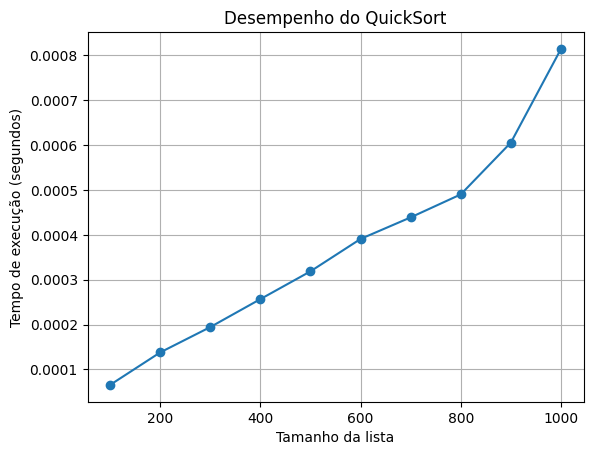

In [2]:
import time
import random
import matplotlib.pyplot as plt

def quicksort(arr):
    # Caso base: lista com 0 ou 1 elemento já está ordenada
    if len(arr) <= 1:
        return arr

    # Escolha do pivô (elemento do meio)
    pivot = arr[len(arr) // 2]

    # Particionamento
    left = [x for x in arr if x < pivot]     # menores
    middle = [x for x in arr if x == pivot]  # iguais
    right = [x for x in arr if x > pivot]    # maiores

    # Recursão + concatenação
    return quicksort(left) + middle + quicksort(right)

# Listas para armazenar resultados
tamanhos = []
tempos = []


# Testes de 100 até 1000 de 100 em 100
for n in range(100, 1001, 100):
    arr = [random.randint(0, 1000) for _ in range(n)]

    inicio = time.perf_counter()
    quicksort(arr)
    fim = time.perf_counter()

    tempo_execucao = fim - inicio

    tamanhos.append(n)
    tempos.append(tempo_execucao)

    print(f"Tamanho: {n} | Tempo: {tempo_execucao:.6f}s")

plt.figure()

plt.plot(tamanhos, tempos, marker='o')

plt.xlabel("Tamanho da lista")
plt.ylabel("Tempo de execução (segundos)")
plt.title("Desempenho do QuickSort")

plt.grid()

plt.show()

Para este teste, o grafico apresentou um crescimento linear, o que indica que o pior caso deixou de ocorrer.

4 - Apresente uma implementação bem detalhada e comentada do algoritmo QuickSelect.

* Faça a análise de complexidade detalhada de seu algoritmo QuickSelect.
* Execute testes de busca de um elemento aleatório sobre listas aleatórias com 25, 50, 75, ... , 950, 975, 1000 elementos, registrando os tempos de execução.
* Plote um gráfico com os resultados e faça uma discussão analisando o gráfico comparativamente com o que você determinou como sendo a ordem de complexidade no item (a).

Análise de Complexidade

* **Melhor caso**<br/>
Sempre divide 2 (metade/metade)<br/>
Elimina metade do problema a cada passo<br/>
Complexidade: $O(n)$<br/>

* **Caso medio**<br/>
Divisões razoavelmente balanceadas<br/>
Só percorre parte da árvore<br/>
Complexidade: $O(n)$<br/>


* **Pior caso**<br/>
Pivô sempre ruim<br/>
Complexidade: $O(n^2)$<br/>


* **Espaço**<br/>
Versão atual: $O(n)$<br/>


Tamanho: 100 | Tempo: 0.000015s
Tamanho: 200 | Tempo: 0.000046s
Tamanho: 300 | Tempo: 0.000034s
Tamanho: 400 | Tempo: 0.000106s
Tamanho: 500 | Tempo: 0.000041s
Tamanho: 600 | Tempo: 0.000070s
Tamanho: 700 | Tempo: 0.000095s
Tamanho: 800 | Tempo: 0.000120s
Tamanho: 900 | Tempo: 0.000097s
Tamanho: 1000 | Tempo: 0.000052s


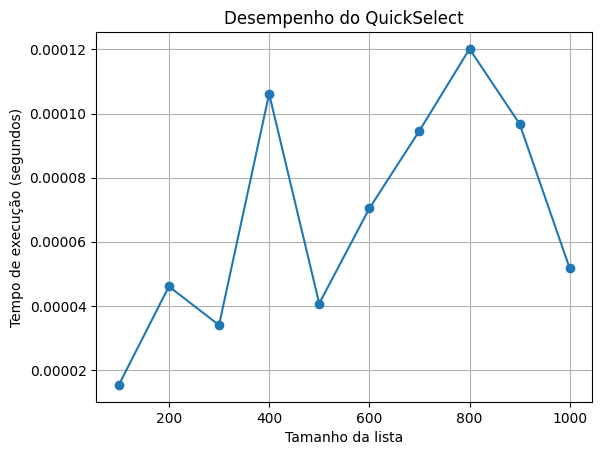

In [3]:
import time
import random
import matplotlib.pyplot as plt

def quickselect(arr, k):
    # Caso base
    if len(arr) == 1:
        return arr[0]

    # Escolha do pivô (elemento do meio)
    pivot = arr[len(arr) // 2]

    # Particionamento
    left = [x for x in arr if x < pivot]     # menores
    middle = [x for x in arr if x == pivot]  # iguais
    right = [x for x in arr if x > pivot]    # maiores

    # Decisão: em qual parte está o k?
    if k < len(left):
        return quickselect(left, k)

    elif k < len(left) + len(middle):
        return pivot

    else:
        return quickselect(right, k - len(left) - len(middle))


# Listas para armazenar resultados
tamanhos = []
tempos = []


# Testes de 100 até 1000 de 100 em 100
for n in range(100, 1001, 100):
    arr = [random.randint(0, 1000) for _ in range(n)]
    
    # Escolhe um índice aleatório (k)
    k = random.randint(0, n - 1)

    inicio = time.perf_counter()
    quickselect(arr, k)
    fim = time.perf_counter()

    tempo_execucao = fim - inicio

    tamanhos.append(n)
    tempos.append(tempo_execucao)

    print(f"Tamanho: {n} | Tempo: {tempo_execucao:.6f}s")


plt.figure()

plt.plot(tamanhos, tempos, marker='o')

plt.xlabel("Tamanho da lista")
plt.ylabel("Tempo de execução (segundos)")
plt.title("Desempenho do QuickSelect")

plt.grid()

plt.show()

Para dados randomicos, o grafico evidencia casos de complexidade $O(n)$ tanto quanto $O(n^2)$

#### Grupo 3: Exercícios para manipular estruturas de dados lineares, incluindo listas encadeadas, listas duplamente encadeadas, com operações de leitura, inserção e exclusão.



5 - Editores de linha podem ser eficientemente implementados através do uso de listas duplamente encadeadas. Esta estrutura permite que linhas de texto sejam facilmente inseridas, excluídas, movidas ou copiadas. Por exemplo, considere o texto a seguir:

"A natureza,<br/>
dizem-nos,<br/>
é apenas o hábito...”<br/>

(Rousseau)

Usando uma lista duplamente encadeada, podemos representá-lo da seguinte maneira:

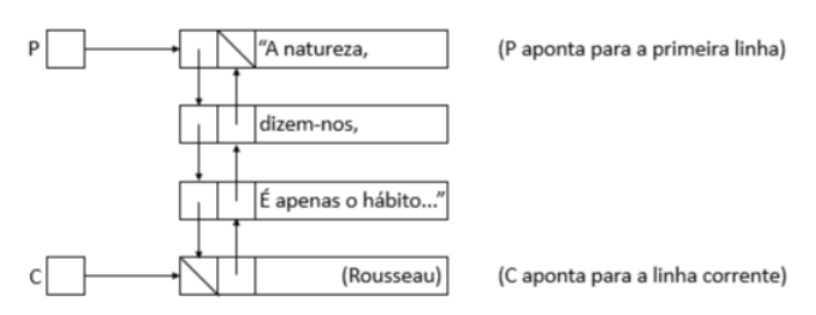

Desenvolva um programa que use listas duplamente encadeadas para fazer representações de texto como ilustrado acima.

Por definição, uma lista duplamente encadeada é uma estrutura de dados linear onde cada nó contém dados e dois ponteiros: um para o próximo nó e outro para o anterior. Isso permite percorrer a lista nas duas direções (frente/trás), facilitando inserções e remoções eficientes, especialmente no final da estrutura. Para este problema, foi pensado no codigo abaixo:

In [4]:
# Classe Nó para gerenciar os nós individuais com seus respectivos ponteiros
class No:
    def __init__(self, linha):
        self.linha = linha # conteúdo do nó
        self.prev = None # ponteiro para o nó prévio
        self.next = None # ponteiro para o nó posterior

class ListaDupla:
    def __init__(self):
        self.inicio = None #inicio da lista
        self.fim = None #fim da lista

    
    def inserir_final(self, texto):
        novo = No(texto) # novo nó

        if self.fim is None: # se o nó final é none, o novo nó se torna o novo início e fim 
            self.inicio = novo
            self.fim = novo
        else:
            novo.prev = self.fim # do contrário ele aponta pro prévio nó prévio existente e o novo nó passa a ser o novo fim
            self.fim.next = novo
            self.fim = novo

    def imprimir(self): #seleciona o início da lista, e percorre imprimindo cada nó individualmente
        atual = self.inicio
        while atual:
            print(atual.linha)
            atual = atual.next


lista = ListaDupla()

lista.inserir_final("A natureza,")
lista.inserir_final("dizem-nos,")
lista.inserir_final("é apenas o hábito...")
lista.inserir_final("(Rousseau)")

lista.imprimir()

A natureza,
dizem-nos,
é apenas o hábito...
(Rousseau)


6 - Baseando-se na estrutura sugerida na Questão 7 (penso que aqui na verdade se refere ao exercício 5), desenvolva um editor de textos, que ofereça ao usuário os seguintes comandos:

I \<n>:

* Entra no modo de inserção, incluindo as novas linhas digitadas após a linha \<n>. Caso o valor \<n> não seja fornecido, a inserção ocorrerá após a linha corrente.

E \<i>,\<f>:

* Exclui as linhas da posição \<i> até a posição \<f>. Caso os parâmetros não sejam fornecidos, apenas a linha corrente deverá ser excluída do texto.

D \<i>,\<f>,\<p>:

* Duplica o bloco de linhas \<i> até \<f> imediatamente após a linha \<p>.

L \<i>,\<f>:

* Lista o bloco de linhas \<i> até \<f>. Caso nenhum parâmetro seja fornecido, todo o texto é listado.

C \<arq>,\<n>:

* Carrega as linhas do arquivo \<arq> para a posição imediatamente após a linha \<n>. Caso \<n> não seja fornecida, ela é assumida como sendo a linha corrente.

S \<arq>,\<i>,\<f>:

* Salva no arquivo \<arq> o conjunto de linhas \<i> até \<f>. Se \<i> e \<f> não são fornecidos, todo o texto é salvo.

A \<n>:

* Permite alterar o texto na linha \<n>.

F:

* Finaliza a execução

Para esse exercício foi elaborado a estrutura de código abaixo:

In [ ]:
class No:
    def __init__(self, texto):
        self.texto = texto
        self.prev = None
        self.next = None

class ListaDupla:
    def __init__(self):
        self.inicio = None
        self.fim = None
        self.tamanho = 0

    def inserir_apos(self, no_ref, novo_no):
        if no_ref is None:
            if self.inicio is None:
                self.inicio = self.fim = novo_no

            else:
                novo_no.next = self.inicio
                self.inicio.prev = novo_no
                self.inicio = novo_no

        else:
            novo_no.prev = no_ref
            novo_no.next = no_ref.next

            if no_ref.next:
                no_ref.next.prev = novo_no

            else:
                self.fim = novo_no

            no_ref.next = novo_no

        self.tamanho += 1

    def remover(self, no):
        if no.prev:
            no.prev.next = no.next

        else:
            self.inicio = no.next

        if no.next:
            no.next.prev = no.prev

        else:
            self.fim = no.prev

        self.tamanho -= 1


    def obter_no(self, pos):
        atual = self.inicio
        i = 1
        while atual and i < pos:
            atual = atual.next
            i += 1
        return atual

class Editor:
    def __init__(self):
        self.lista = ListaDupla()
        self.cursor = None

    def inserir(self, n=None):
        if n is None:
            ref = self.cursor
        else:
            ref = self.lista.obter_no(n)

        print("(modo  de inserção, termine com '.')")

        ultimo = ref

        while True:
            linha = input()
            if linha == ".":
                break

            novo = No(linha)
            self.lista.inserir_apos(ultimo, novo)
            ultimo = novo

        self.cursor = ultimo

    def excluir(self, i=None, f=None):
        if i is None:
            if self.cursor:
                prox = self.cursor.next or self.cursor.prev
                self.lista.remover(self.cursor)
                self.cursor = prox
            return

        inicio = self.lista.obter_no(i)
        fim = self.lista.obter_no(f if f else i)

        atual = inicio
        while atual:
            prox = atual.next
            self.lista.remover(atual)
            if atual == fim:
                break
            atual = prox

        self.cursor = prox if prox else self.lista.fim

    def listar(self, i=None, f=None):
        atual = self.lista.inicio
        linha = 1

        while atual:
            if (i is None or linha >= i) and (f is None or linha <= f):
                print(f"{linha}: {atual.texto}")

            atual = atual.next
            linha += 1


    def alterar(self, n):
        no = self.lista.obter_no(n)
        if not no:
            return

        print("Nova linha: ")
        no.texto = input()
        self.cursor = no

    def salvar(self, arq, i=None, f=None):
        with open(arq, "w") as file:
            atual = self.lista.inicio
            linha = 1

            while atual:
                if (i is None or linha >= i) and (f is None or linha <= f):
                    file.write(atual.texto + "\n")

                atual = atual.next
                linha += 1


    def carregar(self, arq, n=None):
        try:
            with open(arq, "r") as file:
                linhas = file.readlines()

        except:
            print("Erro ao abrir o arquivo")
            return

        ref = self.cursor if n is None else self.lista.obter_no(n)
        ultimo = ref

        for linha in linhas:
            novo = No(linha.strip())
            self.lista.inserir_apos(ultimo, novo)
            ultimo = novo

        self.cursor = ultimo


    def duplicar(self, i, f, p):
        inicio = self.lista.obter_no(i)
        fim = self.lista.obter_no(f)
        pos = self.lista.obter_no(p)

        atual = inicio
        ultimo = pos

        while atual:
            novo = No(atual.texto)
            self.lista.inserir_apos(ultimo, novo)
            ultimo = novo

            if atual == fim:
                break
            atual = atual.next

        self.cursor = ultimo


def executar():
    editor = Editor()

    while True:
        comando = input(">> ").strip()

        if comando == "F":
            break

        if comando.startswith("I"):
            partes = comando.split()
            n = int(partes[1]) if len(partes) > 1 else None
            editor.inserir(n)

        elif comando.startswith("E"):
            if len(comando) > 1:        
                partes = comando[1:].split(",") if len(comando) > 1 else []
                i = int(partes[0]) if partes and partes[0] else None
                f = int(partes[1]) if len(partes) > 1 else None
            else:
                i = f = None
            
            editor.excluir(i, f)

        elif comando.startswith("L"):
            if len(comando) > 1:
                partes = comando[1:].split(",") if len(comando) > 1 else []
                i = int(partes[0]) if partes and partes[0] else None
                f = int(partes[1]) if len(partes) > 1 else None
            else:
                i = f = None
            editor.listar(i, f)

        elif comando.startswith("A"):
            partes = comando.split()
            if len(partes) > 1:
                n = int(partes[1])
                editor.alterar(n)
            else:
                print("erro, informe a linha")

        elif comando.startswith("S"):
            partes = comando.split()
            arq = partes[1] if len(partes) > 1 else "saida.txt"
        
            if len(partes) > 2:
                intervalo = partes[2].split(",")
                i = int(intervalo[0])
                f = int(intervalo[1]) if len(intervalo) > 1 else None
            else:
                i = f = None

            editor.salvar(arq, i, f)

        elif comando.startswith("C"):
            partes = comando.split()
        
            if len(partes) < 2:
                print("Erro: informe o arquivo")
                continue
        
            arq = partes[1]
            n = int(partes[2]) if len(partes) > 2 else None
        
            editor.carregar(arq, n)

        elif comando.startswith("D"):
            if len(comando) <= 1:
                print("Erro: informe i,f,p")
                continue
        
            partes = comando[1:].strip().split(",")
        
            if len(partes) < 3:
                print("Erro: faltam parâmetros")
                continue
        
            i, f, p = map(int, partes)
            editor.duplicar(i, f, p)

        
executar()

#### Grupo 4: Exercícios para resolver problemas complexos empregando diferentes técnicas de algoritmos recursivos.



7 - Imagine que você precisa criar uma ferramenta para varrer o disco rígido de um computador para calcular o tamanho total ocupado por uma pasta. O problema é que uma pasta pode ter outras pastas dentro dela, que têm mais pastas, e assim por diante. Você não sabe quão "fundo" essa estrutura vai.

O Problema:

Escreva uma função recursiva que percorra uma estrutura de dicionários aninhados (que representam as pastas) e some o tamanho de todos os arquivos encontrados no final de cada ramificação.

Exemplo da organização do sistema de arquivos para o teste:

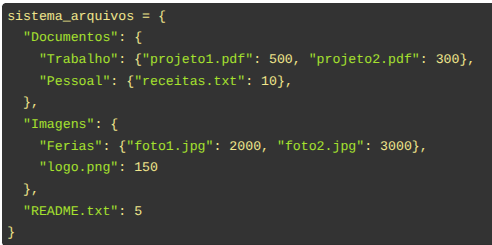

In [15]:
sistema_arquivos = {
    "Documentos": {
        "Trabalho": {
            "projeto1.pdf": 500,
            "projeto2.pdf": 300
        },
        "Pessoal": {
            "receitas.txt": 10
        },
    },
    "Imagens": {
        "Ferias": {
            "foto1.jpg": 2000,
            "foto2.jpg": 3000
        },
        "logo.png": 150
    },
    "README.txt": 5
}

def calcular_tamanho(pasta):
    total = 0

    for nome, conteudo in pasta.items():
        if isinstance(conteudo, int):
            total += conteudo
        elif isinstance(conteudo, dict):
            total += calcular_tamanho(conteudo)

    return total


resultado = calcular_tamanho(sistema_arquivos)
print("Tamanho total:", resultado)

Tamanho total: 5965


8 - Escreva uma função recursiva que imprima uma régua de ordem $n$ no intervalo $[0…2^n]$. O traço no ponto médio da régua deve ter comprimento $n$; os traços nos pontos médios dos subintervalos superior e inferior devem ter comprimento $n−1$
; e assim por diante. A figura mostra uma régua de ordem 4.

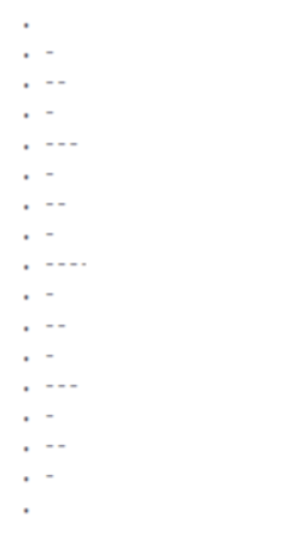

À princípio esse enunciado não fez sentido algum, a nomenclatura de régua remete a estrutura de medidas, o que confundiu bastante. Após uma pesquisa consegui entender o requerido. Foi elaborado conforme abaixo:

In [16]:
def regua(n):
    if n == 0:
        return
    
    regua(n - 1)
    print("-" * n)
    regua(n - 1)

regua(3)

-
--
-
---
-
--
-


#### Grupo 5: Exercícios para orquestrar a navegação e manipulação de estruturas de dados complexas (listas e árvores) utilizando computação paralela com OpenMP para otimizar o desempenho.

9 - Suponha que você tenha uma imagem representada por uma matriz gigante de pixels (inteiros de 0 a 255). Sua tarefa é aplicar um ajuste de brilho em cada pixel. Como a matriz é enorme, processar um pixel por vez de forma sequencial é muito lento.

O Problema:

Escreva um programa que percorra uma matriz de 10.000 × 10.000 e some um valor de brilho a cada elemento. Use as diretivas do OpenMP para distribuir essas linhas entre os núcleos do seu processador.

Requisitosda Tarefa:

* Geração de Dados: Crie uma matriz dinâmica e preencha-a com valores aleatórios.
* Paralelização: Use a diretiva **#pragma omp parallel for** para dividir o loop externo entre as threads.
* Cláusulas: Use **shared** para a matriz e **private** para os índices dos loops $(i, j)$.
* Medição: Compare o tempo de execução com e sem o OpenMP (usando **omp_get_wtime()**).

Para esse exercício, foi pensando do pseudo código abaixo:

'''

    N = 10000
    brilho = 10
    
    alocar matriz[N][N]
    
    // preencher com valores aleatórios
    para i de 0 até N:
        para j de 0 até N:
            matriz[i][j] = random(0..255)
        
    inicio = omp_get_wtime()
    
    #pragma omp parallel for shared(matriz) private(i, j)
    para i de 0 até N:
        para j de 0 até N:
            matriz[i][j] += brilho
    
    fim = omp_get_wtime()
    
    tempo_paralelo = fim - inicio
    
    tempo_sequencial = fim - inicio

'''

Traduzindo o pseudo código pra linguagem C, ficaria algo como:

'''

    #include <stdio.h>
    #include <stdlib.h>
    #include <omp.h>
    
    int main() {
        long long n = 10000;
        int brilho = 10;
    
        double inicio, fim, tempo_seq, tempo_par;
    
        // alocação dinâmica
        int **matriz = malloc(n * sizeof(int *));
        for (long long i = 0; i < n; i++) {
            matriz[i] = malloc(n * sizeof(int));
        }
    
        // preencher com valores aleatórios
        for (long long i = 0; i < n; i++) {
            for (long long j = 0; j < n; j++) {
                matriz[i][j] = rand() % 256;
            }
        }
    
        // =====================
        // SEQUENCIAL
        // =====================
        inicio = omp_get_wtime();
    
        for (long long i = 0; i < n; i++) {
            for (long long j = 0; j < n; j++) {
                matriz[i][j] += brilho;
            }
        }
    
        fim = omp_get_wtime();
        tempo_seq = fim - inicio;
    
        printf("Tempo sequencial: %f\n", tempo_seq);
    
        // =====================
        // PARALELO
        // =====================
        inicio = omp_get_wtime();
    
        #pragma omp parallel for shared(matriz) 
        for (long long i = 0; i < n; i++) {
            for (long long j = 0; j < n; j++) {
                matriz[i][j] += brilho;
            }
        }
    
        fim = omp_get_wtime();
        tempo_par = fim - inicio;
    
        printf("Tempo paralelo: %f\n", tempo_par);
    
        return 0;
    }

'''

No terminal, criei um arquivo chamado ex09.c para essa execução. Após, os mesmos comandos do exercício 1 fora utilizados, "gcc -fopenmp ex09.c -o ex09" e "export OMP_NUM_THREADS=4;./ex09" alterando o número de threads entre 4 e 20, com os seguintes resultados:

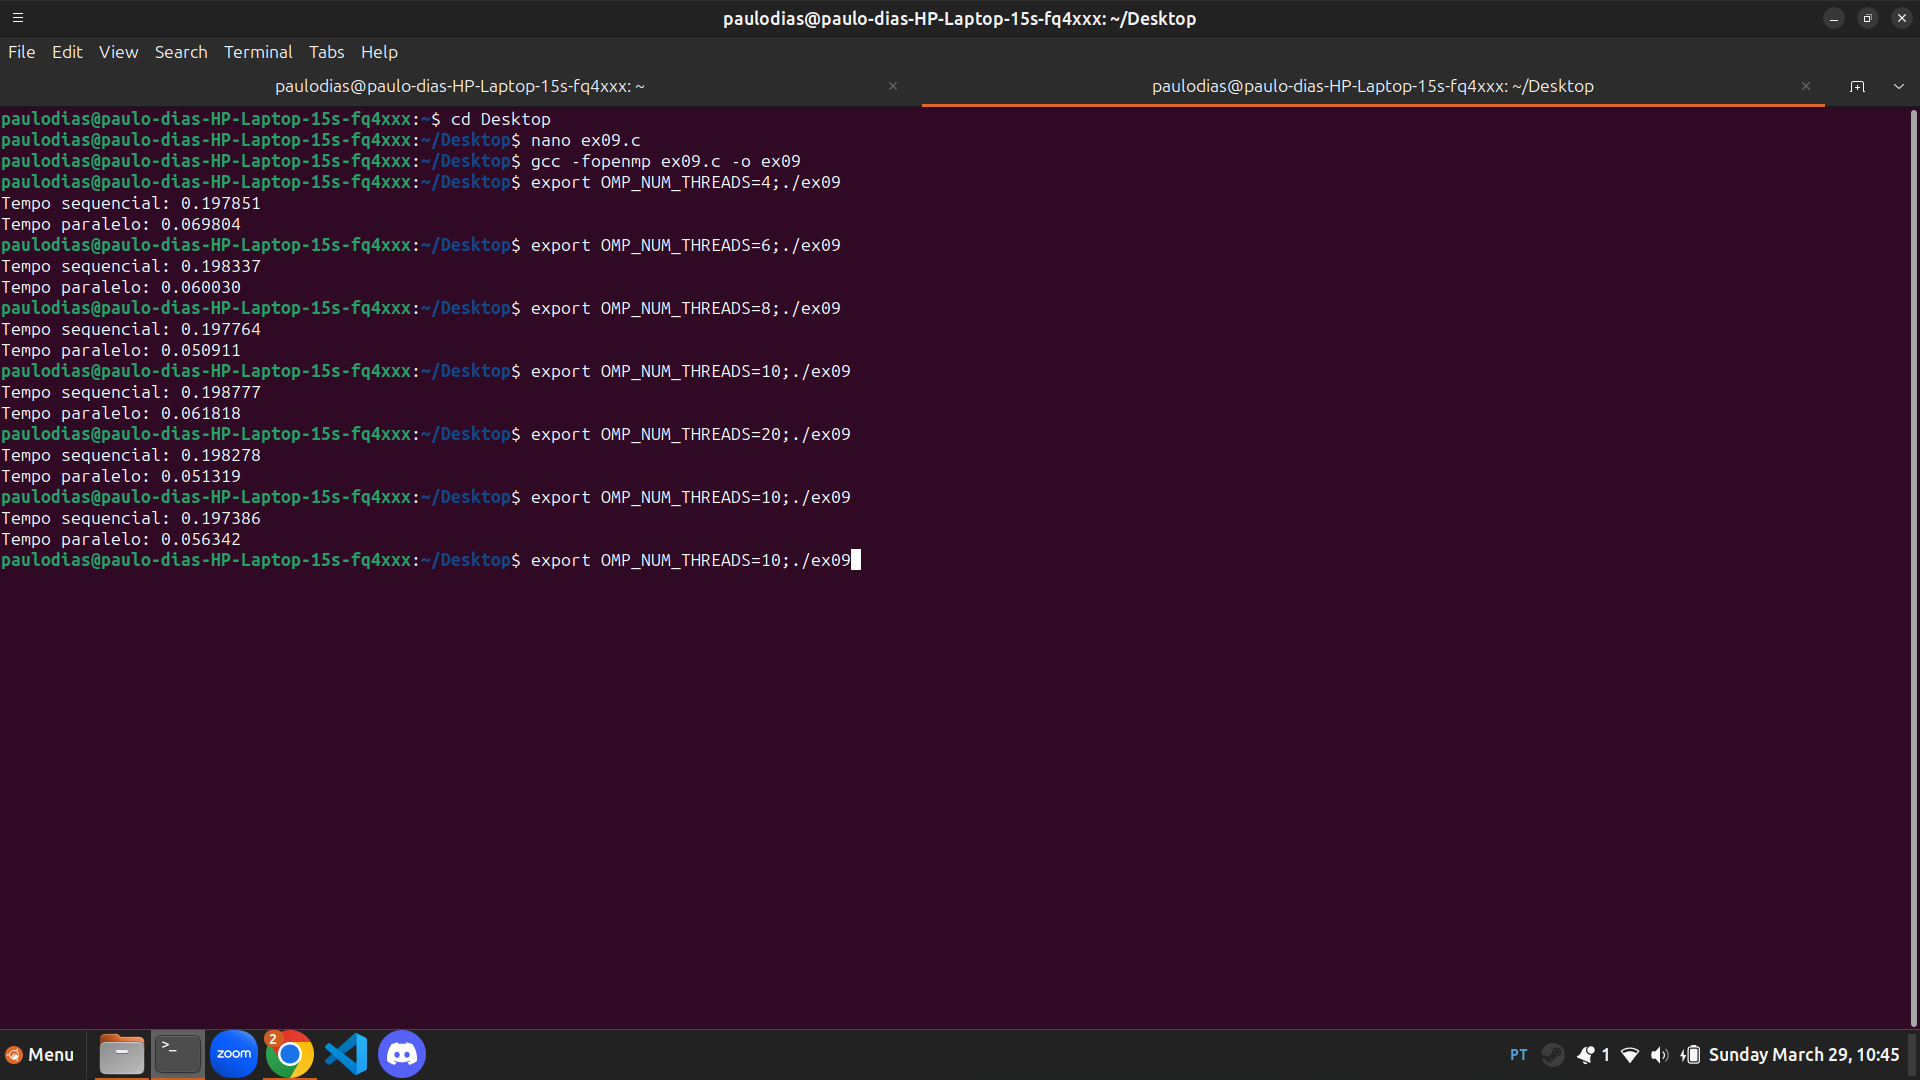

Achei estranho que À primeira tentativa com 10 threads o temp geral subiu, mas após retornou a curva regular


10 - Problema do Produtor e Consumidor

Você está desenvolvendo o sistema de um hospital. Existem sensores enviando batimentos cardíacos (Produtores) e um monitor médico que precisa processar e alertar se o batimento estiver fora do normal (Consumidor). O desafio é que o médico não pode parar de ver os dados antigos enquanto os novos chegam.

O Problema:

Use uma fila da biblioteca asyncio para criar um sistema onde uma tarefa "gera" sinais vitais e outra tarefa "analisa" esses sinais simultaneamente.

Requisitos da Tarefa:

* A Fila: Crie um asyncio.Queue(maxsize=10). Isso evita que o sistema fique sobrecarregado de dados não processados.
* O Produtor (Sensor): Uma corrotina que gera um número aleatório (batimento) entre 40 e 180 a cada 0.5 segundos e coloca na fila.
* O Consumidor (Monitor): Uma corrotina que retira o dado da fila, verifica se o batimento está acima de 120 e imprime: "ALERTA: Batimento em {valor}!" ou "Normal: {valor}".
* Encerramento Elegante: O programa deve rodar por 10 segundos e depois parar as duas tarefas de forma limpa.


In [17]:
import asyncio
import random

async def prod(fila):
    try:
        while True:
            batimento = random.randint(40, 180)
            await fila.put(batimento)
            await asyncio.sleep(0.5)
    except asyncio.CancelledError:
        print("Produtor de batimentos encerrado.")
        raise

async def cons(fila, estatistica):
    try:
        while True:
            batimento = await fila.get()
            if batimento > 120:
                print(f"ALERTA: Batimento em {batimento}!")
                estatistica["alerta"] += 1
            else:
                print(f"Batimento: {batimento}")

            estatistica["total"] += 1
            fila.task_done()
    except asyncio.CancelledError:
        print("Consumidor de batimentos encerrado.")
        raise

async def main():
    fila = asyncio.Queue(maxsize=10)

    estatistica = {"total": 0, "alerta": 0}

    tarefa_prod_batimento = asyncio.create_task(prod(fila))
    tarefa_cons_batimento = asyncio.create_task(cons(fila, estatistica))

    await asyncio.sleep(10)

    tarefa_prod_batimento.cancel()
    tarefa_cons_batimento.cancel()

    await asyncio.gather(tarefa_prod_batimento, tarefa_cons_batimento, return_exceptions=True)

    print("\n ----- RELATÓRIO FINAL ----- \n")
    print(f"Total de leituras: {estatistica['total']}\n")
    print(f"Total de alertas: {estatistica['alerta']}\n")

    if estatistica['total'] > 0:
        porcentagem = (estatistica['alerta'] / estatistica['total']) * 100
        print(f"Percentual de alertas: {porcentagem:.2f}%")

    print("Sistema encerrado.")

await main()   

ALERTA: Batimento em 127!
ALERTA: Batimento em 129!
Batimento: 46
Batimento: 96
ALERTA: Batimento em 174!
Batimento: 99
Batimento: 76
Batimento: 56
Batimento: 55
Batimento: 98
Batimento: 73
Batimento: 85
ALERTA: Batimento em 141!
ALERTA: Batimento em 142!
ALERTA: Batimento em 129!
Batimento: 93
ALERTA: Batimento em 152!
Batimento: 68
Batimento: 87
Batimento: 41
Produtor de batimentos encerrado.
Consumidor de batimentos encerrado.

 ----- RELATÓRIO FINAL ----- 

Total de leituras: 20

Total de alertas: 7

Percentual de alertas: 35.00%
Sistema encerrado.


#### Grupo 6: Exercícios para aplicar programação dinâmica para otimizar e corrigir desafios inerentes à recursão.



11 - Considere a versão clássica do Problema da Linha de Montagem:

* Há duas linhas de montagem, cada uma com $n$ estações.
* A j-ésima estação na linha $i$ é denotada por $s_{i,j}$ e o tempo de montagem nessa estação é $a_{i,j}$.
* Um chassi entra na fábrica e vai para a linha $i$ (onde $i=1$ ou 2), demorando o tempo $e_{i}$.
* Depois de passar pela j-ésima estação em uma linha, o chassi vai para a $(j+1)$-ésima estação de uma das linhas.
* Não há custo de transferência se ele ficar na mesma linha, mas demora o tempo $t_{i,j}$ para transferir a peça para a outra linha após a estação $s_{i,j}$.
* Depois de sair da n-ésima estação em uma linha, decorre o tempo $x_{i}$ para a peça estar pronta.

O problema consiste em determinar que estações escolher na linha 1 e quais escolher na linha 2 de forma a minimizar o tempo total de passagem de uma peça pela fábrica. A figura abaixo ilustra o problema.

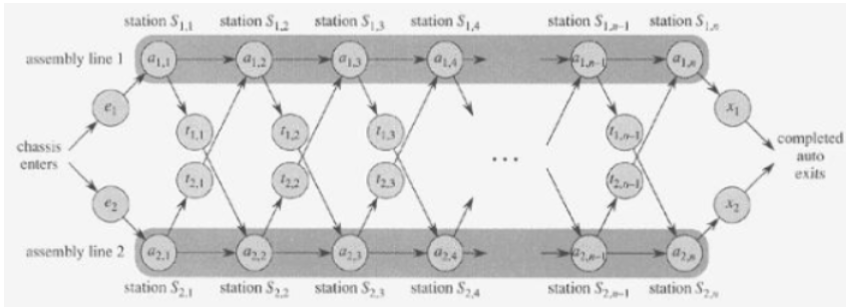

Para a elaboração de uma solução com programação dinâmica, é necessário buscar pela solução recursiva. Apresente e implemente uma solução recursiva do problema clássico da linha de montagem.

Para implementação de sua solução:

* Considere as linhas de montagem com 20 estações cada uma.
* Atribua valores aleatórios para todos os custos relacionados, sendo:<br/>
$1≤e_{i},t_{i,j},x_{i}≤10$<br/>
$1≤a_{i,j}≤20$

12 - Considere agora uma nova versão do problema, desta vez com três linhas de montagem. Apresente e implemente a solução recursiva para a nova versão do problema da linha de montagem. Use as mesmas considerações para execução da questão anterior.